# 📊 Exploratory Data Analysis & Feature Engineering
**Objective:** Analyze the retail credit risk dataset to discover behavioral patterns, identify drivers of loan default, and prototype risk features before pushing them to the production PostgreSQL database.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load the raw dataset
df = pd.read_csv('../data/credit_risk_dataset.csv')

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# Check for missing values and data types
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100,
    'Data Type': df.dtypes
})
display(missing_summary[missing_summary['Missing Values'] > 0])

# Insight: 'person_emp_length' and 'loan_int_rate' have missing values. 
# We will handle these using median imputation in our Scikit-Learn pipeline later.

,Missing Values,Percentage,Data Type
person_emp_length,895,2.747000,float64
loan_int_rate,3116,9.563856,float64


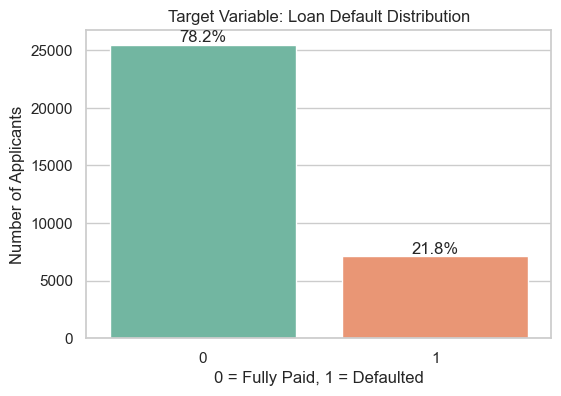

In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='loan_status', palette='Set2')
plt.title("Target Variable: Loan Default Distribution")
plt.xlabel("0 = Fully Paid, 1 = Defaulted")
plt.ylabel("Number of Applicants")

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.show()

# Insight: The dataset is highly imbalanced (~21.8% defaults). 
# This justifies our use of 'scale_pos_weight' and PR-AUC Evals in the XGBoost pipeline.

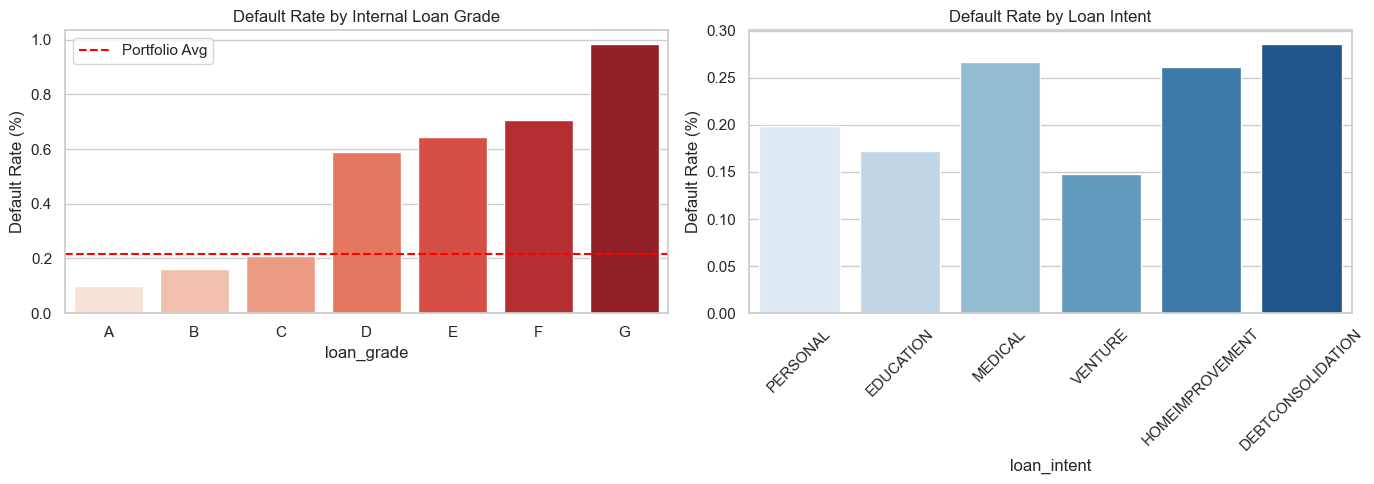

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Default Rate by Loan Grade
grade_order = sorted(df['loan_grade'].dropna().unique())
sns.barplot(data=df, x='loan_grade', y='loan_status', order=grade_order, ax=axes[0], errorbar=None, palette='Reds')
axes[0].set_title("Default Rate by Internal Loan Grade")
axes[0].set_ylabel("Default Rate (%)")
axes[0].axhline(df['loan_status'].mean(), color='red', linestyle='--', label='Portfolio Avg')
axes[0].legend()

# 2. Default Rate by Loan Intent
sns.barplot(data=df, x='loan_intent', y='loan_status', ax=axes[1], errorbar=None, palette='Blues')
axes[1].set_title("Default Rate by Loan Intent")
axes[1].set_ylabel("Default Rate (%)")
axes[1].tick_params(axis='x', rotation=45)

# CORRECTED LINE HERE:
plt.tight_layout()
plt.show()

# Actionable Insight: Grades D, E, F, and G represent extreme risk, far exceeding the portfolio average. 
# Debt Consolidation and Medical loans are the riskiest intents.

### 🛠️ Feature Engineering
Before writing complex SQL window functions for production, we will prototype mathematical risk ratios here using Pandas to see if they hold predictive power.

In [8]:
# Feature 1: Debt-to-Income (DTI) Ratio
df['calculated_dti'] = df['loan_amnt'] / df['person_income'].replace(0, np.nan)

# Feature 2: Interest Rate Spread (Difference from Grade Average)
# This simulates the SQL: AVG(loan_int_rate) OVER(PARTITION BY loan_grade)
grade_avg_rate = df.groupby('loan_grade')['loan_int_rate'].transform('mean')
df['int_rate_spread'] = df['loan_int_rate'] - grade_avg_rate

# Feature 3: Extreme Debt Burden Flag (DTI > 35%)
df['is_high_debt_burden'] = (df['calculated_dti'] > 0.35).astype(int)

display(df[['loan_amnt', 'person_income', 'calculated_dti', 'int_rate_spread', 'is_high_debt_burden']].head())

,loan_amnt,person_income,calculated_dti,int_rate_spread,is_high_debt_burden
0,35000,59000,0.593220,0.658552,1
1,1000,9600,0.104167,0.144445,0
2,5500,9600,0.572917,-0.593542,1
3,35000,65500,0.534351,1.766458,1
4,35000,54400,0.643382,0.806458,1


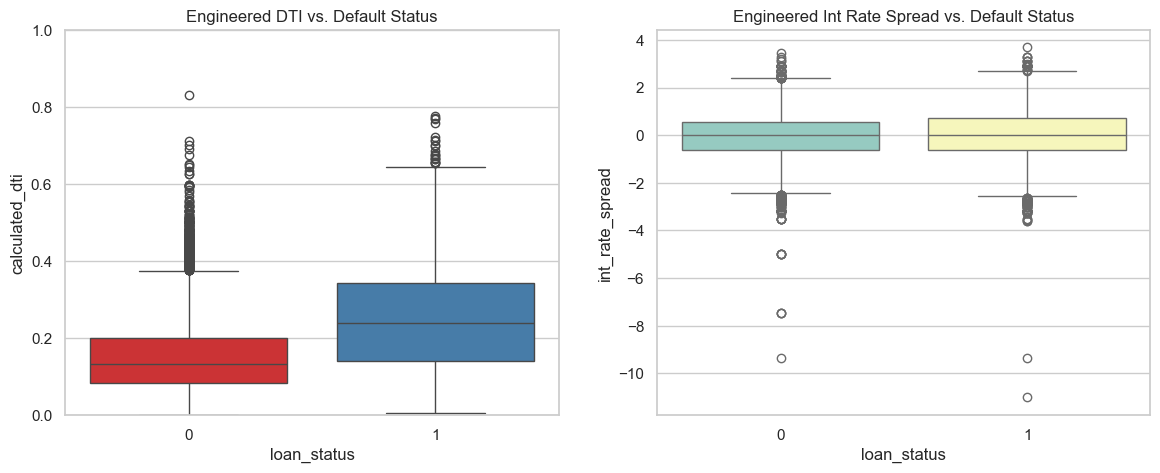

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot DTI vs Default
sns.boxplot(data=df, x='loan_status', y='calculated_dti', ax=axes[0], palette='Set1')
axes[0].set_title("Engineered DTI vs. Default Status")
axes[0].set_ylim(0, 1.0) # Cap at 100% for readability

# Plot Interest Rate Spread vs Default
sns.boxplot(data=df, x='loan_status', y='int_rate_spread', ax=axes[1], palette='Set3')
axes[1].set_title("Engineered Int Rate Spread vs. Default Status")

plt.show()

# Insight: Both engineered features show strong separation! 
# Defaulted loans (1) have significantly higher DTIs and positive Interest Rate Spreads compared to their peers.

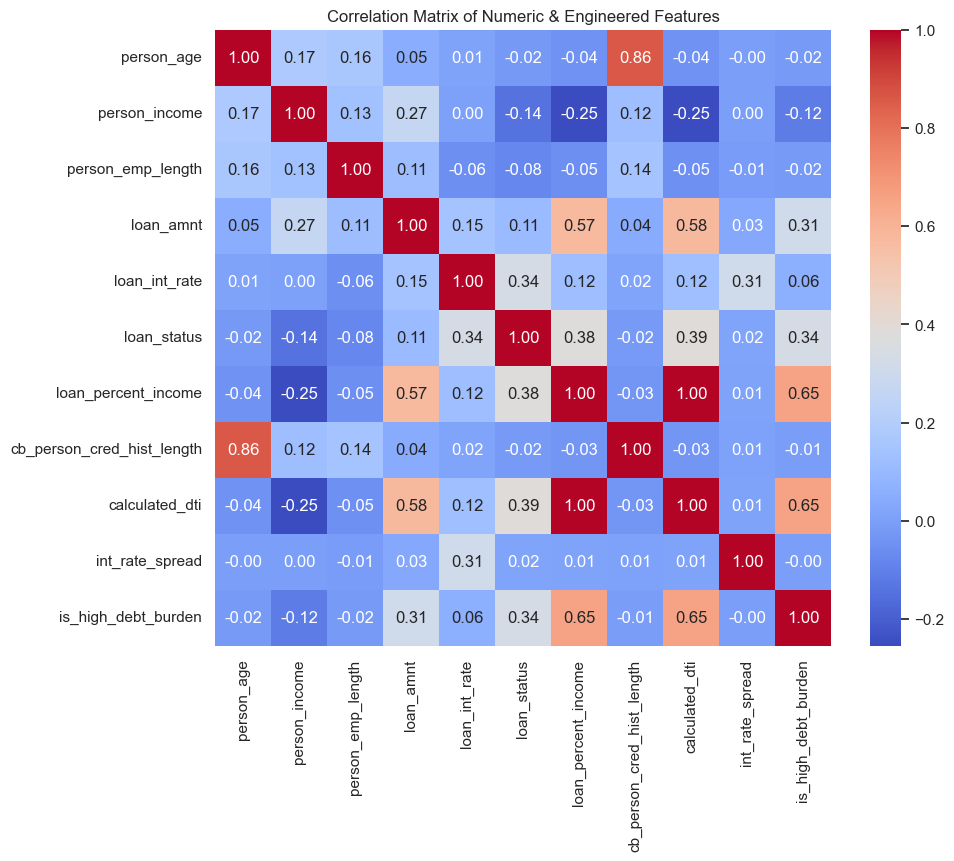

In [10]:
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Matrix of Numeric & Engineered Features")
plt.show()

### 📌 Executive Summary & Actionable Insights
1. **Income vs. Loan Size Disconnect (First Principles):** The fundamental driver of default is cash flow availability. Our engineered `calculated_dti` metric proved highly predictive. Applicants with a DTI > 35% should trigger immediate manual review.
2. **Pricing Risk:** The `int_rate_spread` feature reveals that if a borrower is priced higher than their peer group average (Grade A-G), they are empirically more likely to default. 
3. **Imbalance Strategy:** With a ~21% default rate, accuracy is a flawed metric. The machine learning pipeline must use cost-sensitive learning (`scale_pos_weight` in XGBoost) and be evaluated on Precision-Recall AUC (PR-AUC) to protect the firm's portfolio health.